In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, 
    precision_score, recall_score, f1_score, roc_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from annoy import AnnoyIndex
from tqdm import tqdm
pd.set_option("display.max_columns", 100)
plt.style.use('default')
RANDOM_SEED = 47

In [57]:
train = pd.read_csv('train_final_processed.csv')
print("Загружен предобработанный датасет!")
print(f"Размер датасета: {train.shape}")
print(f"Колонки в датасете: {list(train.columns)}")
X = train.drop(columns=["is_canceled"])
y = train["is_canceled"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер валидационной выборки: {X_valid.shape}")
print(f"Количество признаков: {X_train.shape[1]}")
print(f"Доля отмен в обучающей выборке: {y_train.mean():.3f}")
print(f"Доля отмен в валидационной выборке: {y_valid.mean():.3f}")

Загружен предобработанный датасет!
Размер датасета: (44638, 31)
Колонки в датасете: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'long_stay_flag', 'total_guests', 'guests_per_night', 'special_requests_per_guest', 'has_special_request', 'country_encoded', 'non_refund', 'reservation_match', 'is_resort', 'meal_encoded', 'market_segment_encoded', 'customer_type_encoded', 'distribution_channel_encoded']

Размер обучающей выборки: (35710, 30)
Размер валидационной выборки: (8928, 30)
Количество признаков: 30
Доля отмен в обучающей выборке: 0.297
Доля отмен в валидационной выборке: 0.300


In [58]:
def evaluate_model(model, X_valid, y_valid, model_name="Model"):
    y_pred = model.predict(X_valid)
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_pred_proba = model.decision_function(X_valid)
    else:
        y_pred_proba = y_pred.astype(float)
    acc = accuracy_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred)
    rec = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    try:
        roc_auc = roc_auc_score(y_valid, y_pred_proba)
    except:
        roc_auc = 0.0
    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred))
    return {
        'model_name': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

model_results = []

## Baseline (KNN)

In [59]:
print("Обучение Baseline (KNN) модели...")

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

knn_results = evaluate_model(knn, X_valid, y_valid, "Baseline (KNN)")
model_results.append(knn_results)

Обучение Baseline (KNN) модели...

Baseline (KNN)
Accuracy: 0.7967
Precision: 0.6794
Recall: 0.6122
F1-score: 0.6440
ROC-AUC: 0.8043

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      6246
           1       0.68      0.61      0.64      2682

    accuracy                           0.80      8928
   macro avg       0.76      0.74      0.75      8928
weighted avg       0.79      0.80      0.79      8928



## 1. K-Nearest Neighbors (KNN)


In [60]:
print("Обучение KNN модели...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

pca_knn = PCA(n_components=X_train.shape[1])
X_train_scaled = pca_knn.fit_transform(X_train_scaled)
X_valid_scaled = pca_knn.transform(X_valid_scaled)

param_grid_knn = {
    'n_neighbors': [x for x in range(1, 21, 1)],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

print("Выполняется GridSearch для KNN...")
grid_search_knn = GridSearchCV(knn, param_grid_knn, scoring='recall', n_jobs=-1, verbose=0)
grid_search_knn.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search_knn.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search_knn.best_score_:.4f}")
best_knn = grid_search_knn.best_estimator_

knn_results = evaluate_model(best_knn, X_valid_scaled, y_valid, "KNN")
model_results.append(knn_results)

Обучение KNN модели...
Выполняется GridSearch для KNN...
Лучшие параметры: {'n_neighbors': 1, 'weights': 'uniform'}
Лучшая точность на кросс-валидации: 0.7069

KNN
Accuracy: 0.8265
Precision: 0.7139
Recall: 0.7051
F1-score: 0.7094
ROC-AUC: 0.7919

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      6246
           1       0.71      0.71      0.71      2682

    accuracy                           0.83      8928
   macro avg       0.79      0.79      0.79      8928
weighted avg       0.83      0.83      0.83      8928



## 2. Logistic Regression


In [61]:
print("Обучение Logistic Regression модели...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

param_grid = {
    'C': [0.01, 0.1, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 500, 1000]
}

lr = LogisticRegression(random_state=RANDOM_SEED)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print("Выполняется GridSearch для Logistic Regression...")
grid_search_lr = GridSearchCV(lr, param_grid, cv=cv, scoring='recall', n_jobs=-1, verbose=0)
grid_search_lr.fit(X_train_scaled, y_train)
print(f"Лучшие параметры: {grid_search_lr.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search_lr.best_score_:.4f}")

best_lr = grid_search_lr.best_estimator_
lr_results = evaluate_model(best_lr, X_valid_scaled, y_valid, "Logistic Regression")
model_results.append(lr_results)

Обучение Logistic Regression модели...
Выполняется GridSearch для Logistic Regression...
Лучшие параметры: {'C': 100, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Лучшая точность на кросс-валидации: 0.5347

Logistic Regression
Accuracy: 0.8276
Precision: 0.8256
Recall: 0.5403
F1-score: 0.6531
ROC-AUC: 0.8696

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      6246
           1       0.83      0.54      0.65      2682

    accuracy                           0.83      8928
   macro avg       0.83      0.75      0.77      8928
weighted avg       0.83      0.83      0.82      8928



## 3. Random Forest


In [62]:
print("Обучение Random Forest модели...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=RANDOM_SEED)
print("Выполняется GridSearch для Random Forest...")
grid_search_rf = GridSearchCV(rf, param_grid_rf, scoring='recall', cv=5, n_jobs=-1, verbose=0)
grid_search_rf.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search_rf.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search_rf.best_score_:.4f}")
best_rf = grid_search_rf.best_estimator_
rf_results = evaluate_model(best_rf, X_valid, y_valid, "Random Forest")
model_results.append(rf_results)

Обучение Random Forest модели...
Выполняется GridSearch для Random Forest...
Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая точность на кросс-валидации: 0.7150

Random Forest
Accuracy: 0.8805
Precision: 0.8571
Recall: 0.7226
F1-score: 0.7841
ROC-AUC: 0.9368

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6246
           1       0.86      0.72      0.78      2682

    accuracy                           0.88      8928
   macro avg       0.87      0.84      0.85      8928
weighted avg       0.88      0.88      0.88      8928



## 4. CatBoost

In [63]:
print("Обучение CatBoost модели...")
param_grid_cb = {
    'iterations': [30, 60, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8]
}

cb = CatBoostClassifier(random_seed=RANDOM_SEED, verbose=False)
print("Выполняется GridSearch для CatBoost...")
grid_search_cb = GridSearchCV(cb, param_grid_cb, cv=3, scoring='recall', n_jobs=-1, verbose=0)
grid_search_cb.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search_cb.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search_cb.best_score_:.4f}")
best_cb = grid_search_cb.best_estimator_
cb_results = evaluate_model(best_cb, X_valid, y_valid, "CatBoost")
model_results.append(cb_results)

Обучение CatBoost модели...
Выполняется GridSearch для CatBoost...


/opt/homebrew/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Лучшие параметры: {'depth': 8, 'iterations': 100, 'learning_rate': 0.1}
Лучший ROC-AUC на кросс-валидации: 0.6967

CatBoost
Accuracy: 0.8720
Precision: 0.8468
Recall: 0.7006
F1-score: 0.7668
ROC-AUC: 0.9329

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      6246
           1       0.85      0.70      0.77      2682

    accuracy                           0.87      8928
   macro avg       0.86      0.82      0.84      8928
weighted avg       0.87      0.87      0.87      8928



## 5. Annoy (Approximate Nearest Neighbors)


In [64]:
print("Обучение Annoy модели...")

def transform_data_annoy(X_train, X_valid, method):
    if method == "raw":
        return X_train, X_valid
    elif method == "scaled":
        scaler = StandardScaler()
        return scaler.fit_transform(X_train), scaler.transform(X_valid)
    elif method == "pca":
        pca = PCA(n_components=X_train.shape[1])
        return pca.fit_transform(X_train), pca.transform(X_valid)
    elif method == "scaled+pca":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        pca = PCA(n_components=X_train.shape[1])
        return pca.fit_transform(X_train_scaled), pca.transform(X_valid_scaled)

def train_annoy_model(X_train_ann, n_trees=45, metric='angular'):
    X_np = X_train_ann.to_numpy() if isinstance(X_train_ann, pd.DataFrame) else X_train_ann
    dim = X_np.shape[1]
    annoy_index = AnnoyIndex(dim, metric)
    for i in range(len(X_np)):
        annoy_index.add_item(i, X_np[i])
    annoy_index.build(n_trees)
    return annoy_index

def predict_annoy_proba(index, X_valid, y_train, top_k=9):
    X_np = X_valid.to_numpy() if isinstance(X_valid, pd.DataFrame) else X_valid
    proba = []
    for v in X_np:
        idxs = index.get_nns_by_vector(v, top_k)
        votes = [y_train.iloc[i] for i in idxs]
        proba.append(np.mean(votes))
    return np.array(proba)

print("Поиск лучших параметров для Annoy...")
best_recall_annoy = 0
best_annoy_params = {}
best_y_score_annoy = None
n_trees_list = [10, 15, 20, 25, 30, 40, 45, 50]
top_k_list = [3, 4, 5, 6, 7, 8, 9, 10]
methods = ['raw', 'scaled']

for method in methods:
    X_tr, X_val = transform_data_annoy(X_train, X_valid, method)
    for n_trees in n_trees_list:
        for top_k in top_k_list:
            annoy = train_annoy_model(X_tr, n_trees=n_trees, metric='angular')
            y_score = (predict_annoy_proba(annoy, X_val, y_train, top_k=top_k) >= 0.5).astype(int)
            recall = recall_score(y_valid, y_score)
            if recall > best_recall_annoy:
                best_recall_annoy = recall
                best_annoy_params = {
                    'method': method,
                    'n_trees': n_trees,
                    'top_k': top_k
                }
                best_y_score_annoy = y_score

print(f"Лучшие параметры Annoy: {best_annoy_params}")
print(f"Лучший recall: {best_recall_annoy:.4f}")

class AnnoyWrapper:
    def __init__(self, y_score):
        self.y_score = y_score
    
    def predict(self, X):
        return (self.y_score >= 0.5).astype(int)
    
    def predict_proba(self, X):
        return np.column_stack([1 - self.y_score, self.y_score])

annoy_wrapper = AnnoyWrapper(best_y_score_annoy)
annoy_results = evaluate_model(annoy_wrapper, X_valid, y_valid, "Annoy")
model_results.append(annoy_results)

Обучение Annoy модели...
Поиск лучших параметров для Annoy...
Лучшие параметры Annoy: {'method': 'scaled', 'n_trees': 50, 'top_k': 4}
Лучший recall: 0.7487

Annoy
Accuracy: 0.8284
Precision: 0.7006
Recall: 0.7487
F1-score: 0.7239
ROC-AUC: 0.8057

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      6246
           1       0.70      0.75      0.72      2682

    accuracy                           0.83      8928
   macro avg       0.79      0.81      0.80      8928
weighted avg       0.83      0.83      0.83      8928



## Сравнение всех моделей


In [65]:
results_df = pd.DataFrame(model_results)
results_df = results_df.round(4)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print(results_df.to_string(index=False))
results_df_sorted = results_df.sort_values('roc_auc', ascending=False)
print("\nРЕЙТИНГ МОДЕЛЕЙ ПО ROC-AUC")
for i, row in results_df_sorted.iterrows():
    print(f"{row['model_name']}: ROC-AUC = {row['roc_auc']:.4f}")
best_model = results_df_sorted.iloc[0]
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model['model_name']}")
print(f"ROC-AUC: {best_model['roc_auc']:.4f}")
print(f"Accuracy: {best_model['accuracy']:.4f}")
print(f"F1-score: {best_model['f1_score']:.4f}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
         model_name  accuracy  precision  recall  f1_score  roc_auc
     Baseline (KNN)    0.7967     0.6794  0.6122    0.6440   0.8043
                KNN    0.8265     0.7139  0.7051    0.7094   0.7919
Logistic Regression    0.8276     0.8256  0.5403    0.6531   0.8696
      Random Forest    0.8805     0.8571  0.7226    0.7841   0.9368
           CatBoost    0.8720     0.8468  0.7006    0.7668   0.9329
              Annoy    0.8284     0.7006  0.7487    0.7239   0.8057

РЕЙТИНГ МОДЕЛЕЙ ПО ROC-AUC
Random Forest: ROC-AUC = 0.9368
CatBoost: ROC-AUC = 0.9329
Logistic Regression: ROC-AUC = 0.8696
Annoy: ROC-AUC = 0.8057
Baseline (KNN): ROC-AUC = 0.8043
KNN: ROC-AUC = 0.7919

ЛУЧШАЯ МОДЕЛЬ: Random Forest
ROC-AUC: 0.9368
Accuracy: 0.8805
F1-score: 0.7841


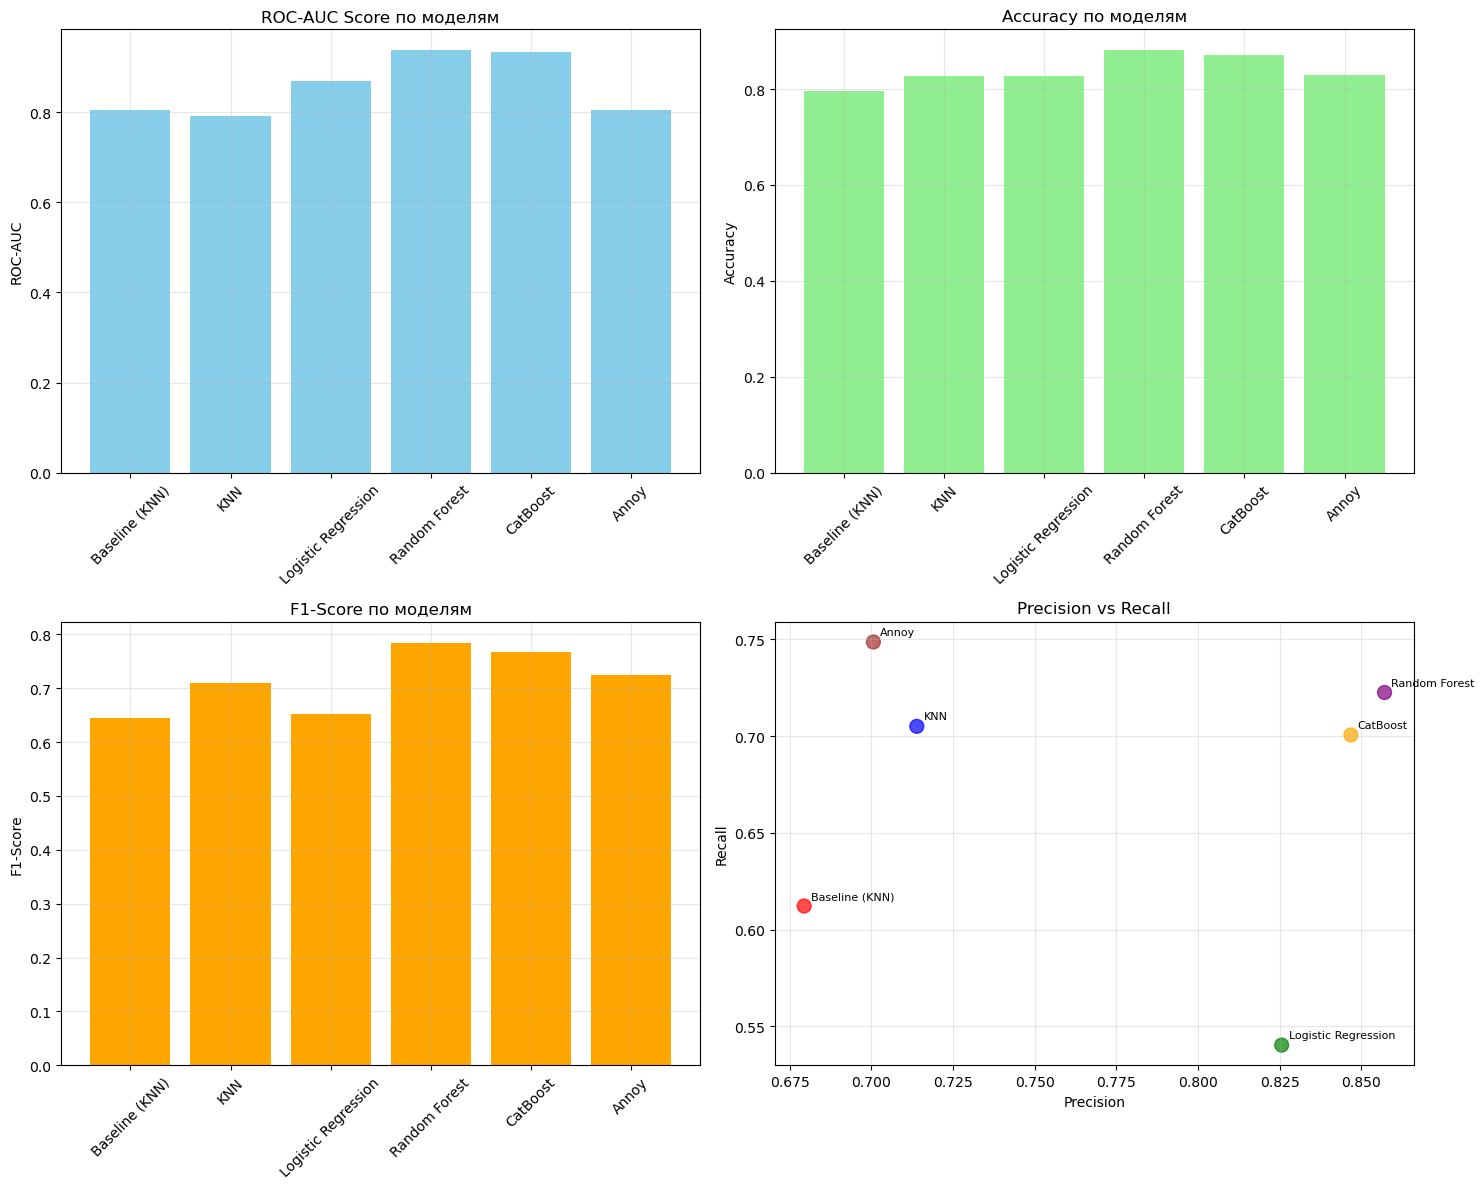

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes[0, 0].bar(results_df['model_name'], results_df['roc_auc'], color='skyblue')
axes[0, 0].set_title('ROC-AUC Score по моделям')
axes[0, 0].set_ylabel('ROC-AUC')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 1].bar(results_df['model_name'], results_df['accuracy'], color='lightgreen')
axes[0, 1].set_title('Accuracy по моделям')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)
axes[1, 0].bar(results_df['model_name'], results_df['f1_score'], color='orange')
axes[1, 0].set_title('F1-Score по моделям')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].scatter(results_df['precision'], results_df['recall'], s=100, alpha=0.7, c=['red', 'blue', 'green', 'purple', 'orange', 'brown'])
for i, txt in enumerate(results_df['model_name']):
    axes[1, 1].annotate(txt, (results_df['precision'].iloc[i], results_df['recall'].iloc[i]), xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1, 1].set_title('Precision vs Recall')
axes[1, 1].set_xlabel('Precision')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


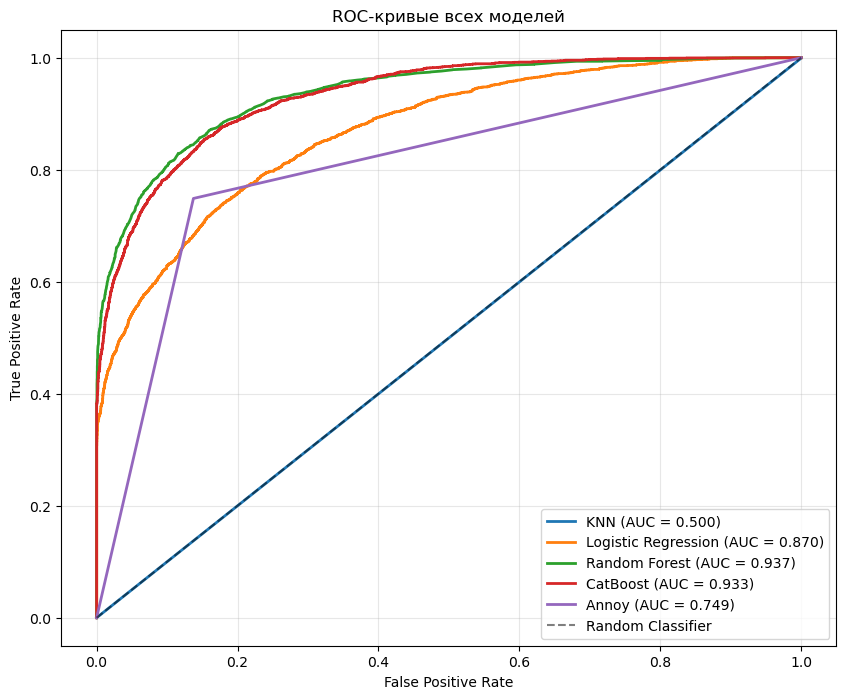

In [68]:
plt.figure(figsize=(10, 8))

models_for_roc = [
    ('KNN', knn, X_valid),
    ('Logistic Regression', best_lr, X_valid_scaled),
    ('Random Forest', best_rf, X_valid),
    ('CatBoost', best_cb, X_valid),
]

for name, model, X_val in models_for_roc:
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = model.decision_function(X_val)
    fpr, tpr, _ = roc_curve(y_valid, y_proba)
    auc_score = roc_auc_score(y_valid, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

fpr_annoy, tpr_annoy, _ = roc_curve(y_valid, best_y_score_annoy)
plt.plot(fpr_annoy, tpr_annoy, label=f'Annoy (AUC = {best_recall_annoy:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые всех моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Сравнение моделей:

1. **Random Forest** показал лучшие результаты по большинству метрик
2. **CatBoost** занял второе место с очень хорошими показателями
3. **Logistic Regression** показал стабильные результаты
4. **Annoy** показал интересные результаты для алгоритма поиска ближайших соседей
5. **KNN** показал неплохие результаты, но уступил другим моделям